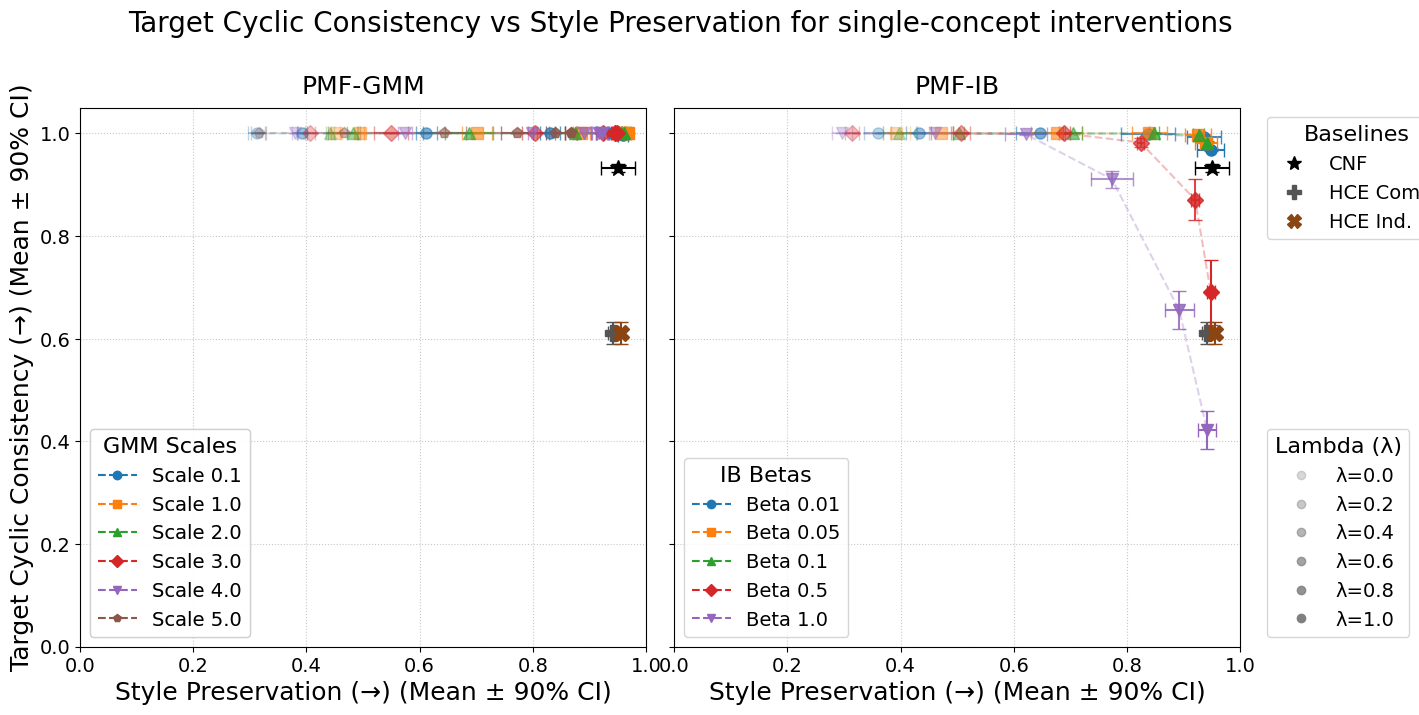

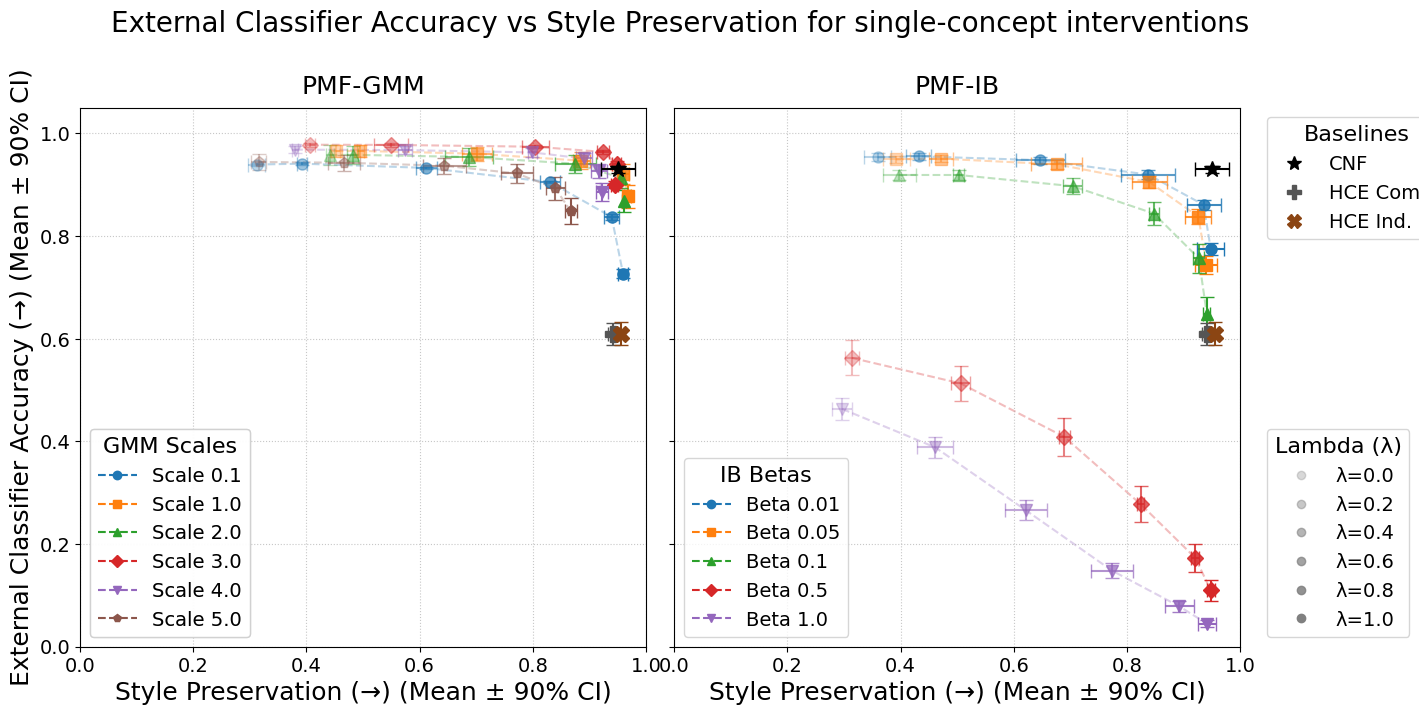

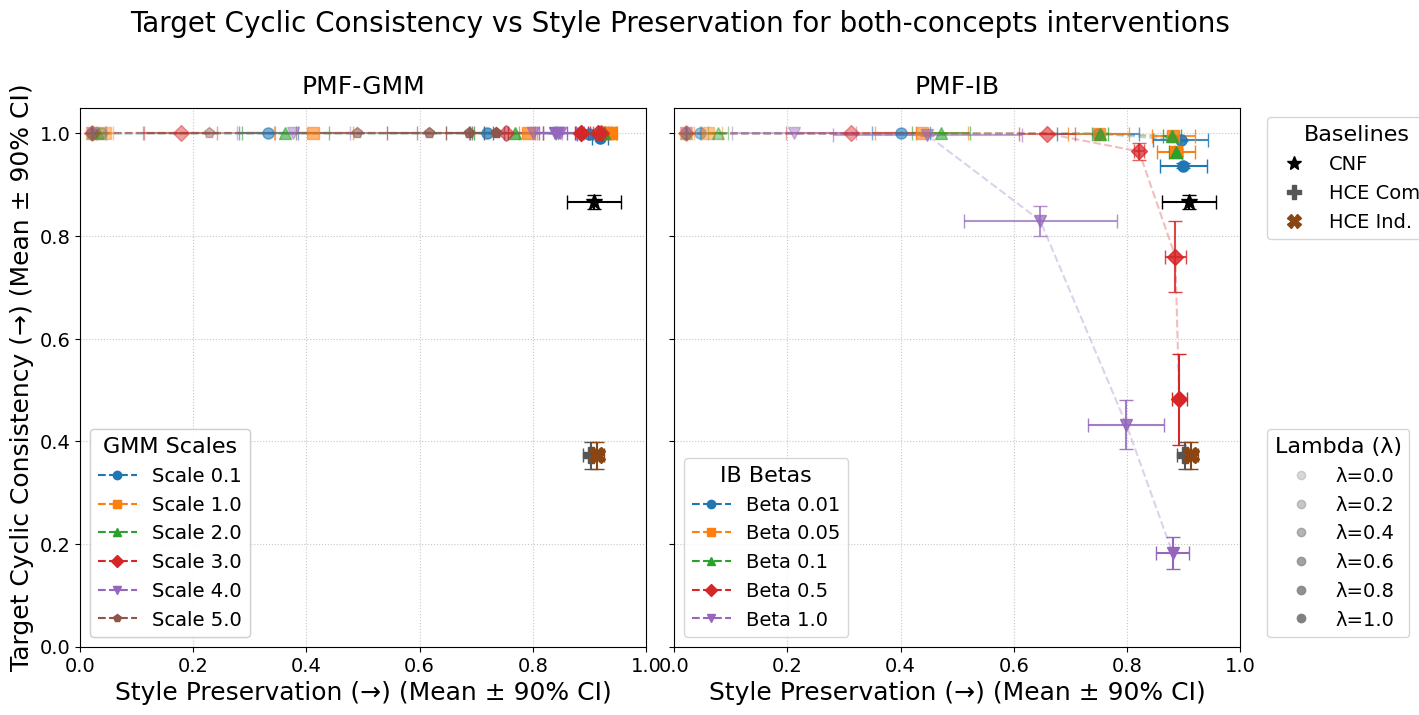

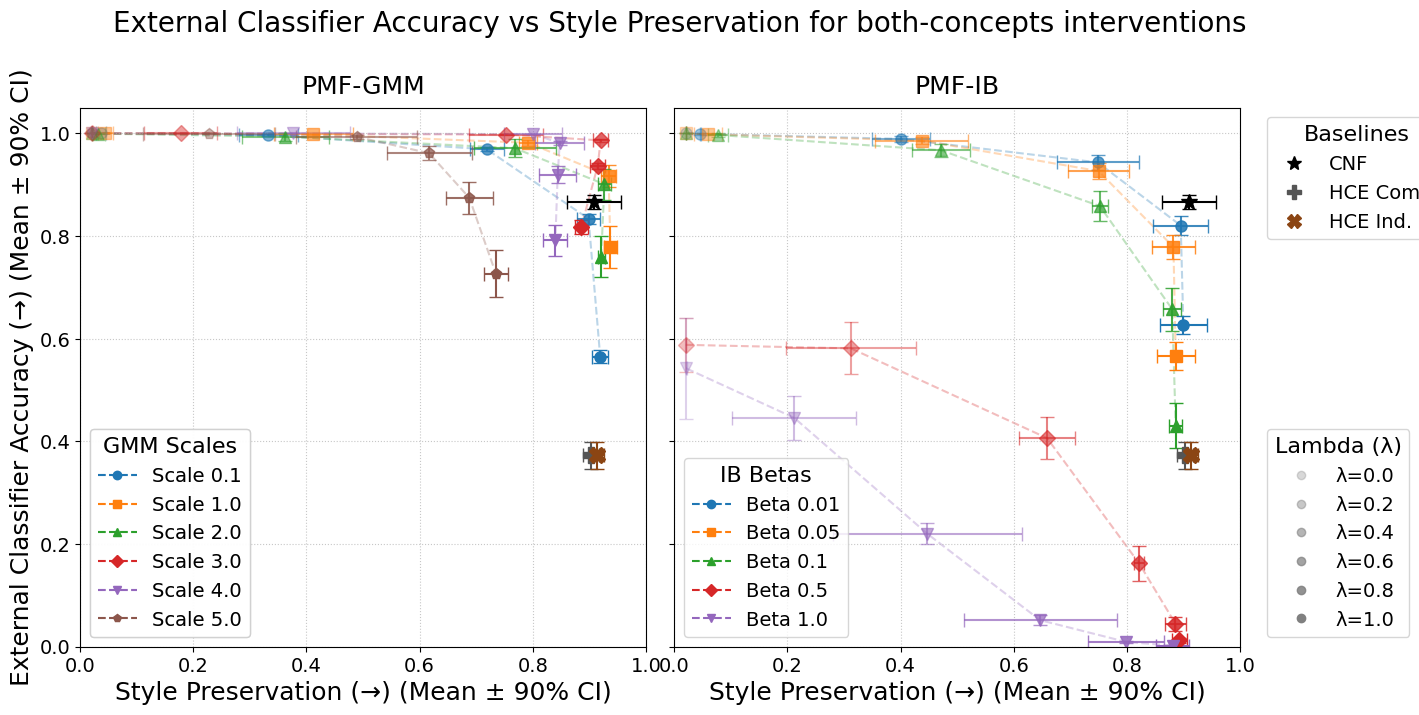

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.lines as mlines

def compute_custom_ci(row, metric_base, dataset, ci_level=90):
    """Helper function to compute custom confidence intervals."""
    raw_cols = [c for c in dataset.columns if c.startswith(f"{metric_base}_") 
                and "mean" not in c and "ci" not in c]
    
    data = row[raw_cols].dropna().values.astype(float)
    n = len(data)
    
    if n < 2:
        return 0.0 
        
    se = stats.sem(data)
    alpha = 1 - (ci_level / 100.0)
    t_val = stats.t.ppf(1 - (alpha / 2), n - 1)
    return se * t_val

def _plot_model_data(ax, csv_dict, int_type, x_metric, y_metric, ci_level, valid_lambdas, cmap, markers):
    """Helper function to read, compute, and plot model data on a specific axis."""
    handles = []
    
    for idx, (config_label, csv_path) in enumerate(csv_dict.items()):
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Warning: File not found -> {csv_path}. Skipping {config_label}.")
            continue
        
        df_filtered = df[
            (df['lambda'] != "tilde") &
            (df['intervention_group'] == int_type)
        ].copy()
        
        if df_filtered.empty:
            continue
            
        df_filtered['lambda'] = df_filtered['lambda'].astype(float)
        df_filtered = df_filtered.sort_values(by="lambda")
        
        x_ci_col = f"{x_metric}_ci_{ci_level}"
        y_ci_col = f"{y_metric}_ci_{ci_level}"
        
        df_filtered[x_ci_col] = df_filtered.apply(lambda row: compute_custom_ci(row, x_metric, df_filtered, ci_level), axis=1)
        df_filtered[y_ci_col] = df_filtered.apply(lambda row: compute_custom_ci(row, y_metric, df_filtered, ci_level), axis=1)
        
        x_mean_col = f"{x_metric}_mean"
        y_mean_col = f"{y_metric}_mean"
        
        x_means = df_filtered[x_mean_col]
        x_errs = df_filtered[x_ci_col]
        y_means = df_filtered[y_mean_col]
        y_errs = df_filtered[y_ci_col]
        lambdas = df_filtered['lambda']
        
        base_color = cmap(idx % 10)
        base_marker = markers[idx % len(markers)]
        
        handles.append(
            mlines.Line2D([], [], color=base_color, marker=base_marker, linestyle='--', label=config_label)
        )
        
        ax.plot(x_means, y_means, linestyle='--', color=base_color, alpha=0.3, zorder=1)
        
        for i, lam in enumerate(lambdas):
            point_alpha = 0.3 + 0.7 * (lam / max(valid_lambdas))
            
            ax.errorbar(
                x_means.iloc[i], y_means.iloc[i], 
                xerr=x_errs.iloc[i], yerr=y_errs.iloc[i], 
                fmt=base_marker,  
                capsize=5,
                color=base_color, 
                ecolor=base_color, 
                alpha=point_alpha,
                markersize=8,
                zorder=2 
            )
            
    return handles

def plot_side_by_side_metrics(
    gmm_csv_dict,
    ib_csv_dict,
    baseline_dict,
    x_metric="style_overall", 
    y_metric="cc_target", 
    int_type="AGGREGATE_1_INTERVENTION", 
    ci_level=90, 
    save_path="plot.png"
):
    
    fonts = {
        'title': 20,
        'axes_labels': 18,
        'tick_labels': 14,
        'legend_title': 16,
        'legend_text': 14
    }

    label_map = {
        "cc_target": "Target Cyclic Consistency",
        "disc_overall_acc": "External Classifier Accuracy",
        "style_overall": "Style Preservation",
        "both": "both-concepts interventions",
        "AGGREGATE_1_INTERVENTION": "single-concept interventions"
    }

    save_path = "plots/tradeoff_unified/" + save_path
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    clean_x_label = label_map.get(x_metric, x_metric)
    clean_y_label = label_map.get(y_metric, y_metric)
    clean_int_type = label_map.get(int_type, int_type)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
    
    cmap = plt.colormaps.get_cmap('tab10')
    markers = ['o', 's', '^', 'D', 'v', 'p', '<', 'h']
    valid_lambdas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

    gmm_handles = _plot_model_data(ax1, gmm_csv_dict, int_type, x_metric, y_metric, ci_level, valid_lambdas, cmap, markers)
    ib_handles = _plot_model_data(ax2, ib_csv_dict, int_type, x_metric, y_metric, ci_level, valid_lambdas, cmap, markers)

    baseline_handles = []
    if baseline_dict is not None:
        baseline_colors = ['#000000', '#555555', '#8b4513'] 
        baseline_markers = ['*', 'P', 'X'] 

        for b_idx, (b_label, b_path) in enumerate(baseline_dict.items()):
            try:
                b_df = pd.read_csv(b_path)
            except FileNotFoundError:
                continue
            
            if 'intervention_group' in b_df.columns:
                b_df_filtered = b_df[b_df['intervention_group'] == int_type].copy()
            else:
                b_df_filtered = b_df.copy()

            if b_df_filtered.empty:
                continue

            b_x_metric = "cc_overall" if x_metric == "disc_overall_acc" else x_metric
            b_y_metric = "cc_overall" if y_metric == "disc_overall_acc" else y_metric
            
            b_x_mean_col = f"{b_x_metric}_mean"
            b_y_mean_col = f"{b_y_metric}_mean"

            if b_x_mean_col not in b_df_filtered.columns or b_y_mean_col not in b_df_filtered.columns:
                continue

            b_row = b_df_filtered.iloc[0]
            b_x_mean = b_row[b_x_mean_col]
            b_y_mean = b_row[b_y_mean_col]
            b_x_err = compute_custom_ci(b_row, b_x_metric, b_df_filtered, ci_level)
            b_y_err = compute_custom_ci(b_row, b_y_metric, b_df_filtered, ci_level)

            b_color = baseline_colors[b_idx % len(baseline_colors)]
            b_marker = baseline_markers[b_idx % len(baseline_markers)]

            for ax in (ax1, ax2):
                ax.errorbar(
                    b_x_mean, b_y_mean, 
                    xerr=b_x_err, yerr=b_y_err, 
                    fmt=b_marker, capsize=5, color=b_color, ecolor=b_color, markersize=12, zorder=3 
                )

            baseline_handles.append(
                mlines.Line2D([], [], color=b_color, marker=b_marker, linestyle='None', markersize=10, label=b_label)
            )

    main_title = fig.suptitle(f"{clean_y_label} vs {clean_x_label} for {clean_int_type}", fontsize=fonts['title'], y=1.02)
    
    ax1.set_title("PMF-GMM", fontsize=fonts['axes_labels'], pad=10)
    ax2.set_title("PMF-IB", fontsize=fonts['axes_labels'], pad=10)
    
    ax1.set_ylabel(f"{clean_y_label} (→) (Mean ± {ci_level}% CI)", fontsize=fonts['axes_labels'])
    ax1.set_xlabel(f"{clean_x_label} (→) (Mean ± {ci_level}% CI)", fontsize=fonts['axes_labels'])
    ax2.set_xlabel(f"{clean_x_label} (→) (Mean ± {ci_level}% CI)", fontsize=fonts['axes_labels'])
    
    for ax in (ax1, ax2):
        ax.tick_params(axis='both', which='major', labelsize=fonts['tick_labels'])
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
    
    leg_gmm = ax1.legend(handles=gmm_handles, title="GMM Scales", loc='lower left',
                         fontsize=fonts['legend_text'], title_fontsize=fonts['legend_title'])
    ax1.add_artist(leg_gmm) 
    
    leg_ib = ax2.legend(handles=ib_handles, title="IB Betas", loc='lower left',
                        fontsize=fonts['legend_text'], title_fontsize=fonts['legend_title'])
    ax2.add_artist(leg_ib)
    
    leg_base = ax2.legend(handles=baseline_handles, title="Baselines", loc='upper left', bbox_to_anchor=(1.03, 1.0),
                          fontsize=fonts['legend_text'], title_fontsize=fonts['legend_title'])
    ax2.add_artist(leg_base)

    lambda_handles = []
    for lam in valid_lambdas:
        alpha_val = 0.3 + 0.7 * (lam / max(valid_lambdas))
        lambda_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='None', alpha=alpha_val, label=f"λ={lam}"))
        
    leg_lam = ax2.legend(handles=lambda_handles, title="Lambda (λ)", loc='lower left', bbox_to_anchor=(1.03, 0.0),
                         fontsize=fonts['legend_text'], title_fontsize=fonts['legend_title'])

    plt.subplots_adjust(right=0.85, wspace=0.05) 
    
    plt.savefig(save_path, dpi=300, bbox_extra_artists=(leg_base, leg_lam, main_title), bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    
    gmm_csvs = {
        "Scale 0.1": "csv/GMM_Scale_0.1/cyc_cons_GMM_0.1_aggregate.csv",
        "Scale 1.0": "csv/GMM_Scale_1.0/cyc_cons_GMM_1.0_aggregate.csv",
        "Scale 2.0": "csv/GMM_Scale_2.0/cyc_cons_GMM_2.0_aggregate.csv",
        "Scale 3.0": "csv/GMM_Scale_3.0/cyc_cons_GMM_3.0_aggregate.csv",
        "Scale 4.0": "csv/GMM_Scale_4.0/cyc_cons_GMM_4.0_aggregate.csv",
        "Scale 5.0": "csv/GMM_Scale_5.0/cyc_cons_GMM_5.0_aggregate.csv"
    }

    ib_csvs = {
        "Beta 0.01": "csv/IB_Beta_0.01/cyc_cons_IB_0.01_aggregate.csv",
        "Beta 0.05": "csv/IB_Beta_0.05/cyc_cons_IB_0.05_aggregate.csv",
        "Beta 0.1": "csv/IB_Beta_0.1/cyc_cons_IB_0.1_aggregate.csv",
        "Beta 0.5": "csv/IB_Beta_0.5/cyc_cons_IB_0.5_aggregate.csv",
        "Beta 1.0": "csv/IB_Beta_1.0/cyc_cons_IB_1.0_aggregate.csv"
    }

    my_baselines = {
        "CNF": "csv/Conditional/cyc_cons_Conditional_aggregate.csv",
        "HCE Comb.": "csv/Gaussian/combinatorial/cyc_cons_Gaussian_combinatorial_aggregate.csv",
        "HCE Ind.": "csv/Gaussian/independent/cyc_cons_Gaussian_independent_aggregate.csv"
    }

    plot_side_by_side_metrics(
        gmm_csvs, ib_csvs, my_baselines,
        x_metric="style_overall", y_metric="cc_target", 
        int_type="AGGREGATE_1_INTERVENTION", 
        save_path="unified_style_vs_cc_target_agg.png"
    )
    
    plot_side_by_side_metrics(
        gmm_csvs, ib_csvs, my_baselines,
        x_metric="style_overall", y_metric="disc_overall_acc", 
        int_type="AGGREGATE_1_INTERVENTION", 
        save_path="unified_style_vs_disc_agg.png"
    )

    plot_side_by_side_metrics(
        gmm_csvs, ib_csvs, my_baselines,
        x_metric="style_overall", y_metric="cc_target", 
        int_type="both", 
        save_path="unified_style_vs_cc_target_both.png"
    )
    
    plot_side_by_side_metrics(
        gmm_csvs, ib_csvs, my_baselines,
        x_metric="style_overall", y_metric="disc_overall_acc", 
        int_type="both", 
        save_path="unified_style_vs_disc_both.png"
    )